<a href="https://colab.research.google.com/github/SANGRAMLEMBE/Computer_Vision_from_Scratch/blob/main/2_Building_Deep_2_layer_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wandb

In [ ]:
import wandb


## **5 Steps from Previous Model**

Image batch Shape: (16, 224, 224, 3)
Label batch Shape: (16,)
Labels: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1]


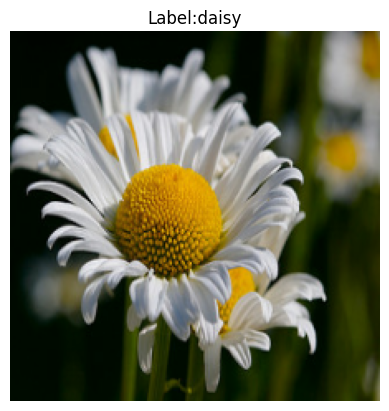

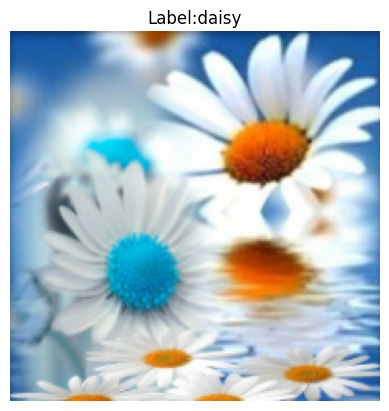

In [ ]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# we are using predefined function from TensorFlow

def read_and_decode(filename, resize_dims):
  # 1. Read the raw file
  img_bytes = tf.io.read_file(filename)

  #2. Decode image data
  img = tf.image.decode_jpeg(img_bytes, channels = IMG_CHANNELS)

  #3. Convert pixel values to floats in [0,1]
  img = tf.image.convert_image_dtype(img, tf.float32)

  #4. Resize the image to match desired dimentions
  img = tf.image.resize(img,resize_dims)

  return img

def parse_csvline(csv_line):

  # record_default specify the data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)

  #Load the Image
  img  = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

  # Convert label string to integer based on the CLASS_NAMES index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))


  return img, label


# Define datasets
train_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
  )          # we defined batch size = 16

eval_dataset = (
    tf.data.TextLineDataset("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch, label_batch in train_dataset.take(1):
  print("Image batch Shape:", image_batch.shape)
  print("Label batch Shape:", label_batch.shape)
  print("Labels:", label_batch.numpy())


import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):

  #Take the first image from the batch
  first_image = image_batch[0]
  first_label = label_batch[0]


  # Conver Tensor To Numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label:{CLASS_NAMES[first_label]}")
  plt.axis('off')
  plt.show()


# New Model With 2 Hidden Layer

In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

model= keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH,3)),
    tf.keras.layers.Dense(128, activation = "relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = "adam",
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

# we defining 2 layes sequentialy (flatten and Dense)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Training and Validation

In [ ]:
model.compile(
    optimizer = Adam(learning_rate = 0.1),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)
